# 01b — Feature Engineering

Builds candidate engineered features, measures whether each one actually contributes to predictive performance (ablation + feature importance/correlation), and separately questions whether any of the original 21 raw features are weak enough to drop. Requires `01_eda.ipynb` to have been run first (needs `data/diabetes_sampled.csv`).

**Output:** `data/diabetes_sampled_final.csv` (raw features, with weak ones dropped, plus whichever engineered features passed the ablation check) and `data/dropped_features.json` (a short record of what was added/dropped and why, for reference in the report). Whether the rest of the pipeline actually uses this file is controlled by `config.USE_ENGINEERED_FEATURES` (default `True`) — see `02_preprocessing.ipynb`.

In [1]:
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, roc_auc_score

from config import DATA_DIR, SAMPLED_CSV, SAMPLED_ENGINEERED_CSV, DROPPED_FEATURES_JSON, TARGET_COL, TEST_SIZE, RANDOM_STATE

RAW_FEATURE_COLS = [
    "HighBP", "HighChol", "CholCheck", "BMI", "Smoker", "Stroke", "HeartDiseaseorAttack",
    "PhysActivity", "Fruits", "Veggies", "HvyAlcoholConsump", "AnyHealthcare", "NoDocbcCost",
    "GenHlth", "MentHlth", "PhysHlth", "DiffWalk", "Sex", "Age", "Education", "Income",
]

# Ablation decision thresholds — transparent, adjustable constants rather than hardcoded verdicts.
F1_IMPROVEMENT_THRESHOLD = 0.002   # an engineered feature must beat baseline F1 by at least this much to be kept
WEAK_RAW_F1_DROP_THRESHOLD = 0.002  # a raw feature can be dropped if removing it costs less than this much F1
WEAK_RAW_IMPORTANCE_PERCENTILE = 10  # ...and its own importance is in the bottom 10% of all raw features

## Load the EDA sample

In [2]:
if not SAMPLED_CSV.exists():
    raise FileNotFoundError(
        f"Could not find {SAMPLED_CSV}. Run 01_eda.ipynb first to generate it."
    )

sample = pd.read_csv(SAMPLED_CSV)
print(f"Sample shape: {sample.shape}")

Sample shape: (40000, 22)


## Engineered feature candidates

Four candidates commonly discussed in public analyses of this dataset. Each is built here and checked below — none are assumed useful until the ablation test says so.

### 1. BMI category (WHO cutoffs)

Underweight (<18.5), Normal (18.5–25), Slightly Overweight (25–30), Overweight (30-40), Obese (>40). Raw BMI is continuous but the health-risk relationship is known to be non-linear across these bands, so a categorical version can capture threshold effects a linear model might miss.

In [17]:
engineered = sample.copy()

bmi_bins = [0, 18.5, 25, 30, 40, engineered["BMI"].max() + 1]
bmi_labels = ["Underweight", "Normal", "Slightly_Overweight", "Overweight", "Obese"]
engineered["BMI_Category"] = pd.cut(engineered["BMI"], bins=bmi_bins, labels=bmi_labels)

print(engineered["BMI_Category"].value_counts())
engineered.groupby("BMI_Category", observed=True)[TARGET_COL].mean()

BMI_Category
Slightly_Overweight    14230
Normal                 13675
Overweight              9718
Obese                   1882
Underweight              495
Name: count, dtype: int64


BMI_Category
Underweight            0.052525
Normal                 0.064497
Slightly_Overweight    0.125791
Overweight             0.231529
Obese                  0.332094
Name: Diabetes_binary, dtype: float64

### 2. Composite cardiometabolic risk score

Sum of six binary risk flags: `HighBP + HighChol + Stroke + HeartDiseaseorAttack + DiffWalk + Smoker` (range 0–6). A simple additive comorbidity count is a common way to combine several individually weak binary flags into one variable that reflects cumulative risk burden.

In [18]:
risk_flags = ["HighBP", "HighChol", "Stroke", "HeartDiseaseorAttack", "DiffWalk", "Smoker"]
engineered["RiskScore"] = engineered[risk_flags].sum(axis=1)

print(engineered["RiskScore"].value_counts().sort_index())
engineered.groupby("RiskScore")[TARGET_COL].mean()

RiskScore
0.0     9160
1.0    11863
2.0     9509
3.0     5905
4.0     2487
5.0      909
6.0      167
Name: count, dtype: int64


RiskScore
0.0    0.026092
1.0    0.071146
2.0    0.164371
3.0    0.264352
4.0    0.349015
5.0    0.451045
6.0    0.526946
Name: Diabetes_binary, dtype: float64

### 3. Total unhealthy days

`MentHlth + PhysHlth` (range 0–60) — collapses two correlated "days not good in past 30 days" counts into a single overall health-burden signal. Note: some public analyses find this adds little beyond `GenHlth`, since it captures a similar underlying construct — this is exactly the kind of claim the ablation test below is meant to check rather than take on faith.

In [19]:
engineered["TotalUnhealthyDays"] = engineered["MentHlth"] + engineered["PhysHlth"]

print(f"Correlation with GenHlth: {engineered['TotalUnhealthyDays'].corr(engineered['GenHlth']):.3f}")
engineered[["TotalUnhealthyDays", TARGET_COL]].groupby(TARGET_COL).mean()

Correlation with GenHlth: 0.516


,TotalUnhealthyDays
Diabetes_binary,
0.0,6.651959
1.0,12.386147


### 4. Elderly flag (Age ≥ 65)

`Age` is already an ordinal 13-level code (1=18-24 ... 13=80+); code 10 corresponds to the 65-69 band, so `Age >= 10` marks 65+. A binary re-bucketing is easier to interpret in the report than the raw 13-level code, at the cost of losing some resolution within the older age groups.

In [20]:
engineered["IsElderly"] = (engineered["Age"] >= 10).astype(int)

engineered.groupby("IsElderly")[TARGET_COL].mean()

IsElderly
0    0.102207
1    0.207933
Name: Diabetes_binary, dtype: float64

## Contribution analysis — ablation

For each engineered feature, train the same Random Forest configuration (matching `03_train_models.ipynb`'s hyperparameters) on baseline raw features alone vs. baseline + that one engineered feature, on a fixed train/test split. A feature is only worth keeping if it moves F1 by more than `F1_IMPROVEMENT_THRESHOLD`.

In [21]:
ablation_df = pd.get_dummies(engineered, columns=["BMI_Category"], prefix="BMI")

X_all = ablation_df.drop(columns=[TARGET_COL])
y_all = ablation_df[TARGET_COL]

X_train_full, X_test_full, y_train, y_test = train_test_split(
    X_all, y_all, test_size=TEST_SIZE, stratify=y_all, random_state=RANDOM_STATE
)


def fit_eval(cols):
    model = RandomForestClassifier(
        n_estimators=200, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1
    )
    model.fit(X_train_full[cols], y_train)
    y_pred = model.predict(X_test_full[cols])
    y_proba = model.predict_proba(X_test_full[cols])[:, 1]
    return {
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_proba),
    }, model

In [22]:
bmi_dummy_cols = [c for c in ablation_df.columns if c.startswith("BMI_")]
engineered_candidates = {
    "BMI_Category": bmi_dummy_cols,
    "RiskScore": ["RiskScore"],
    "TotalUnhealthyDays": ["TotalUnhealthyDays"],
    "IsElderly": ["IsElderly"],
}

baseline_metrics, _ = fit_eval(RAW_FEATURE_COLS)
print(f"Baseline (raw features only): {baseline_metrics}")

ablation_results = [{"Feature": "Baseline (raw only)", **baseline_metrics}]
kept_engineered_features = []

for feat_name, feat_cols in engineered_candidates.items():
    metrics, _ = fit_eval(RAW_FEATURE_COLS + feat_cols)
    delta_f1 = metrics["F1"] - baseline_metrics["F1"]
    ablation_results.append({"Feature": f"+ {feat_name}", **metrics, "F1_delta": delta_f1})
    if delta_f1 > F1_IMPROVEMENT_THRESHOLD:
        kept_engineered_features.append(feat_name)

# All four engineered features together
all_engineered_cols = [c for cols in engineered_candidates.values() for c in cols]
all_metrics, _ = fit_eval(RAW_FEATURE_COLS + all_engineered_cols)
ablation_results.append({
    "Feature": "+ all engineered",
    **all_metrics,
    "F1_delta": all_metrics["F1"] - baseline_metrics["F1"],
})

ablation_table = pd.DataFrame(ablation_results)
ablation_table

Baseline (raw features only): {'F1': 0.14906832298136646, 'ROC_AUC': 0.8169582279016905}


,Feature,F1,ROC_AUC,F1_delta
0,Baseline (raw only),0.149068,0.816958,NaN
1,+ BMI_Category,0.154440,0.814734,0.005372
2,+ RiskScore,0.151585,0.816543,0.002517
3,+ TotalUnhealthyDays,0.145426,0.816721,-0.003642
4,+ IsElderly,0.148722,0.816031,-0.000346
5,+ all engineered,0.165653,0.813039,0.016585


**Decision so far:** an engineered feature is kept only if adding it alone improved F1 by more than the threshold above. This avoids keeping a feature just because the "all engineered" combination happens to score well — some individual features may be riding on the others.

In [23]:
print(f"Engineered features kept after ablation (F1 improvement > {F1_IMPROVEMENT_THRESHOLD}):")
print(kept_engineered_features if kept_engineered_features else "None — no engineered feature cleared the threshold.")

Engineered features kept after ablation (F1 improvement > 0.002):
['BMI_Category', 'RiskScore']


## Contribution analysis — feature importance & correlation

A second, complementary view: fit one Random Forest on raw + all engineered features, and look at `feature_importances_` plus each engineered feature's correlation with the raw features it was built from (to flag multicollinearity).

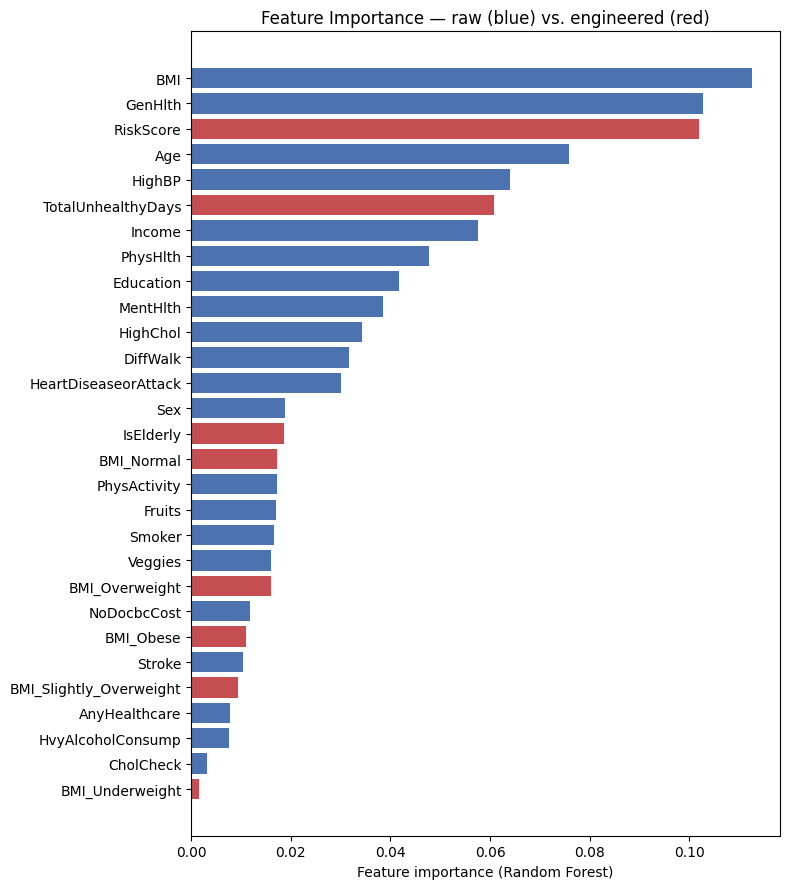

In [24]:
full_metrics, full_model = fit_eval(RAW_FEATURE_COLS + all_engineered_cols)
importances = pd.Series(full_model.feature_importances_, index=RAW_FEATURE_COLS + all_engineered_cols)
importances = importances.sort_values()

fig, ax = plt.subplots(figsize=(8, 9))
colors = ["#C44E52" if c in all_engineered_cols else "#4C72B0" for c in importances.index]
ax.barh(importances.index, importances.values, color=colors)
ax.set_xlabel("Feature importance (Random Forest)")
ax.set_title("Feature Importance — raw (blue) vs. engineered (red)")
fig.tight_layout()
plt.show()

In [25]:
print("Correlation of engineered features with their source raw features (multicollinearity check):")
print(f"  RiskScore vs HighBP:            {engineered['RiskScore'].corr(engineered['HighBP']):.3f}")
print(f"  RiskScore vs HeartDiseaseorAttack: {engineered['RiskScore'].corr(engineered['HeartDiseaseorAttack']):.3f}")
print(f"  TotalUnhealthyDays vs GenHlth:   {engineered['TotalUnhealthyDays'].corr(engineered['GenHlth']):.3f}")
print(f"  IsElderly vs Age:                {engineered['IsElderly'].corr(engineered['Age']):.3f}")

Correlation of engineered features with their source raw features (multicollinearity check):
  RiskScore vs HighBP:            0.654
  RiskScore vs HeartDiseaseorAttack: 0.513
  TotalUnhealthyDays vs GenHlth:   0.516
  IsElderly vs Age:                0.766


**Interpretation note:** a composite feature (e.g. `RiskScore`) is, by construction, correlated with the raw binary flags it sums — that alone isn't disqualifying (tree-based models tolerate redundant/correlated features reasonably well), but it does mean any importance the composite "gets" is partly borrowed from features already in the model. The ablation test above is the more decisive signal; this section is a sanity check on *why* a feature scored the way it did.

## Weak raw feature review

Public analyses of this dataset flag a few raw features as low-value: `CholCheck` (≈95%+ of respondents are 1 — nearly constant) and `HvyAlcoholConsump` (≈95%+ are 0 — heavily imbalanced). We test this directly with the same ablation logic in reverse: does *removing* a raw feature cost the model anything?

A raw feature is dropped only if **both** hold:
1. Removing it costs less than `WEAK_RAW_F1_DROP_THRESHOLD` in F1, **and**
2. Its own importance (from the full model above) is in the bottom `WEAK_RAW_IMPORTANCE_PERCENTILE`% of all raw features.

Requiring both avoids dropping a feature that scores low on one criterion only by chance.

In [26]:
candidate_weak_features = ["CholCheck", "HvyAlcoholConsump", "AnyHealthcare", "NoDocbcCost", "Fruits", "Veggies"]

raw_importances = importances[RAW_FEATURE_COLS]
importance_cutoff = np.percentile(raw_importances.values, WEAK_RAW_IMPORTANCE_PERCENTILE)

removal_results = []
features_to_drop = []

for feat in candidate_weak_features:
    reduced_cols = [c for c in RAW_FEATURE_COLS if c != feat]
    metrics, _ = fit_eval(reduced_cols)
    f1_cost = baseline_metrics["F1"] - metrics["F1"]
    own_importance = raw_importances[feat]
    is_weak = (f1_cost < WEAK_RAW_F1_DROP_THRESHOLD) and (own_importance <= importance_cutoff)
    removal_results.append({
        "Feature": feat,
        "F1_without": metrics["F1"],
        "F1_cost_of_removal": f1_cost,
        "Own_importance": own_importance,
        "Importance_cutoff (bottom 10%)": importance_cutoff,
        "Drop?": is_weak,
    })
    if is_weak:
        features_to_drop.append(feat)

removal_table = pd.DataFrame(removal_results)
removal_table

,Feature,F1_without,F1_cost_of_removal,Own_importance,Importance_cutoff (bottom 10%),Drop?
0,CholCheck,0.157529,-0.008461,0.003164,0.007714,True
1,HvyAlcoholConsump,0.144410,0.004658,0.007527,0.007714,False
2,AnyHealthcare,0.147630,0.001438,0.007714,0.007714,True
3,NoDocbcCost,0.154560,-0.005491,0.011818,0.007714,False
4,Fruits,0.159073,-0.010005,0.017082,0.007714,False
5,Veggies,0.150271,-0.001203,0.015980,0.007714,False


In [27]:
print("Raw features to drop (low importance AND negligible F1 cost when removed):")
print(features_to_drop if features_to_drop else "None — every candidate contributed more than the threshold allows.")

Raw features to drop (low importance AND negligible F1 cost when removed):
['CholCheck', 'AnyHealthcare']


## Final decision and save

Assembles the final feature set: original sample, minus dropped raw features, plus kept engineered features (as their proper dtype — dummy-encoded for `BMI_Category`, numeric for the rest). Saved separately from `diabetes_sampled.csv` so `01_eda.ipynb`'s output is untouched.

In [28]:
final_df = sample.drop(columns=features_to_drop).copy()

if "BMI_Category" in kept_engineered_features:
    final_df = pd.concat([final_df, pd.get_dummies(engineered["BMI_Category"], prefix="BMI")], axis=1)
if "RiskScore" in kept_engineered_features:
    final_df["RiskScore"] = engineered["RiskScore"]
if "TotalUnhealthyDays" in kept_engineered_features:
    final_df["TotalUnhealthyDays"] = engineered["TotalUnhealthyDays"]
if "IsElderly" in kept_engineered_features:
    final_df["IsElderly"] = engineered["IsElderly"]

final_df.to_csv(SAMPLED_ENGINEERED_CSV, index=False)
print(f"Saved final feature set to {SAMPLED_ENGINEERED_CSV}")
print(f"Shape: {final_df.shape} (original sample: {sample.shape})")
print(f"Engineered features kept: {kept_engineered_features}")
print(f"Raw features dropped: {features_to_drop}")

Saved final feature set to C:\Users\ardao\Desktop\Projects\Bil476\data\diabetes_sampled_final.csv
Shape: (40000, 26) (original sample: (40000, 22))
Engineered features kept: ['BMI_Category', 'RiskScore']
Raw features dropped: ['CholCheck', 'AnyHealthcare']


In [29]:
decision_record = {
    "baseline_metrics": baseline_metrics,
    "engineered_features_kept": kept_engineered_features,
    "engineered_features_dropped": [f for f in engineered_candidates if f not in kept_engineered_features],
    "ablation_table": ablation_table.to_dict(orient="records"),
    "raw_features_dropped": features_to_drop,
    "raw_feature_removal_table": removal_table.to_dict(orient="records"),
    "thresholds": {
        "F1_IMPROVEMENT_THRESHOLD": F1_IMPROVEMENT_THRESHOLD,
        "WEAK_RAW_F1_DROP_THRESHOLD": WEAK_RAW_F1_DROP_THRESHOLD,
        "WEAK_RAW_IMPORTANCE_PERCENTILE": WEAK_RAW_IMPORTANCE_PERCENTILE,
    },
}

with open(DROPPED_FEATURES_JSON, "w") as f:
    json.dump(decision_record, f, indent=2)

print(f"Saved decision record to {DROPPED_FEATURES_JSON}")

Saved decision record to C:\Users\ardao\Desktop\Projects\Bil476\data\dropped_features.json
